Q1 Write a Python program that loads a dataset, splits it into training and testing sets, applies Logistic
Regression, and prints the model accuracy

In [2]:
#import necessary libraries 
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.multiclass import OneVsOneClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score, f1_score, roc_auc_score,roc_curve
from sklearn.metrics import cohen_kappa_score, precision_recall_curve, average_precision_score, matthews_corrcoef
from sklearn.pipeline import make_pipeline
from sklearn.datasets import load_iris, make_classification
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore') 

In [51]:

# Load dataset (Iris dataset as an example
from sklearn.datasets import load_iris
data = load_iris()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target

# Split dataset into features and target variable
X = df.drop(columns=['target'])
y = df['target']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Logistic Regression model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate and print model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 1.00


Q2 Write a Python program to apply L1 regularization (Lasso) on a dataset using LogisticRegression(penalty='l1')
    and print the model accuracy

In [52]:

# loading  dataset
from sklearn.datasets import  load_iris
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Split dataset into features and target variable
X = df.drop(columns=['target'])
y = df['target']


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train logistic regression with L1 penalty (Lasso)
model = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Compute and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.4f}')

Model Accuracy: 0.9667


In [ ]:
Q3  Write a Python program to train Logistic Regression with L2 regularization (Ridge) using
    LogisticRegression(penalty='l2'). Print model accuracy and coefficientsC

In [53]:

# Generate a sample dataset (Iris dataset as an example)
from sklearn.datasets import load_iris
data = load_iris()
X = data.data  # Features
y = (data.target == 1).astype(int)  # Binary classification (Setosa vs. non-Setosa)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (important for Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression with L2 regularization
model = LogisticRegression(penalty='l2', solver='lbfgs')
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print results
print(f'Model Accuracy: {accuracy:.4f}')
print('Model Coefficients:', model.coef_)

Model Accuracy: 0.8000
Model Coefficients: [[ 0.25326282 -1.28458216  0.55762082 -0.74156884]]


Q4  Write a Python program to train Logistic Regression with Elastic Net Regularization (penalty='elasticnet')

In [54]:

# Generate a sample dataset (Iris dataset as an example)
data = load_iris()
X = data.data  # Features
y = (data.target == 1).astype(int)  # Binary classification (Setosa vs. non-Setosa)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression with Elastic Net regularization
log_reg = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, solver='saga', max_iter=1000)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8000


Q5 Write a Python program to train a Logistic Regression model for multiclass classification using
    multi_class='ovr'

In [55]:

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Labels

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression model with multi_class='ovr'
model = LogisticRegression(multi_class ='ovr', solver='liblinear')
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.97
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


Q6  Write a Python program to apply GridSearchCV to tune the hyperparameters (C and penalty) of Logistic
    Regression. Print the best parameters and accuracy

In [61]:

# Load the Iris dataset
data = load_iris()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define the parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Initialize the Logistic Regression model
log_reg = LogisticRegression(solver='liblinear', max_iter=1000)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best parameters and the corresponding accuracy
best_params = grid_search.best_params_
best_accuracy = grid_search.best_score_

# Print the best parameters and accuracy
print(f"Best Parameters: {best_params}")
print(f"Best Accuracy: {best_accuracy:.4f}")

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")

Best Parameters: {'C': 10, 'penalty': 'l2'}
Best Accuracy: 0.9524
Test Accuracy: 1.0000


In [ ]:
Q7 Write a Python program to evaluate Logistic Regression using Stratified K-Fold Cross-Validation. Print the
 average accuracy

In [62]:

# Load a sample dataset
data = load_iris()
X = data.data
y = data.target

# Create a Logistic Regression model with standardization
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=200))

# Set up Stratified K-Fold Cross-Validation
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate the model using cross-validation
scores = cross_val_score(model, X, y, cv=stratified_kfold, scoring='accuracy')

# Print the average accuracy
print(f'Average Accuracy: {scores.mean():.4f}')

Average Accuracy: 0.9533


In [ ]:
Q8 Write a Python program to load a dataset from a CSV file, apply Logistic Regression, and evaluate its
accuracy.

In [63]:



def load_data(csv_file):
    """Load dataset from a CSV file."""
    return pd.read_csv(csv_file)

def preprocess_data(df, target_column):
    """Preprocess data by splitting into features and target and standardizing features."""
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Standardize features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    return X_train, X_test, y_train, y_test

def train_logistic_regression(X_train, y_train):
    """Train a Logistic Regression model."""
    model = LogisticRegression()
    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_test, y_test):
    """Evaluate the model's accuracy."""
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    return accuracy, report

if __name__ == "__main__":
    # Specify your CSV file path
    csv_file = "iris.csv"  # Update with your file path
    target_column = "target"  # Update with the actual target column
    
    # Load and preprocess data
    df = load_data(csv_file)
    X_train, X_test, y_train, y_test = preprocess_data(df, target_column)
        
    # Train model
    model = train_logistic_regression(X_train, y_train)
    
    # Evaluate model
    accuracy, report = evaluate_model(model, X_test, y_test)
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", report)

Accuracy: 1.0000
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Q9 Write a Python program to apply RandomizedSearchCV for tuning hyperparameters (C, penalty, solver) in
    Logistic Regression. Print the best parameters and accuracy

In [64]:

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model
log_reg = LogisticRegression(multi_class='auto', max_iter=500)

# Define hyperparameter grid
param_dist = {
    'C': np.logspace(-4, 4, 20),
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'solver': ['liblinear', 'lbfgs', 'saga']
}

# Apply RandomizedSearchCV
random_search = RandomizedSearchCV(log_reg, param_distributions=param_dist, n_iter=20, cv=5, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

# Print best parameters
print("Best Parameters:", random_search.best_params_)

# Evaluate on test data
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)


Best Parameters: {'solver': 'saga', 'penalty': 'l2', 'C': 0.615848211066026}
Test Accuracy: 1.0


Q10 Write a Python program to implement One-vs-One (OvO) Multiclass Logistic Regression and print accuracy

In [65]:

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create and train One-vs-One Logistic Regression model
ovo_clf = OneVsOneClassifier(LogisticRegression(max_iter=200))
ovo_clf.fit(X_train, y_train)

# Make predictions
y_pred = ovo_clf.predict(X_test)

# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')


Accuracy: 100.00%


In [ ]:
Q11 Write a Python program to train a Logistic Regression model and visualize the confusion matrix for binary
    classification

In [10]:

#read titanic.csv file from working  directory
df = pd.read_csv('titanic.csv')

# Selecting relevant features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
df = df[features + ['Survived']]

# Handling missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encoding categorical variables

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Split the dataset into training and testing sets
# Splitting dataset
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression model with multi_class='ovr'
#model = LogisticRegression(multi_class ='ovr', solver='liblinear')
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

Confusion Matrix:
[[90 15]
 [19 55]]


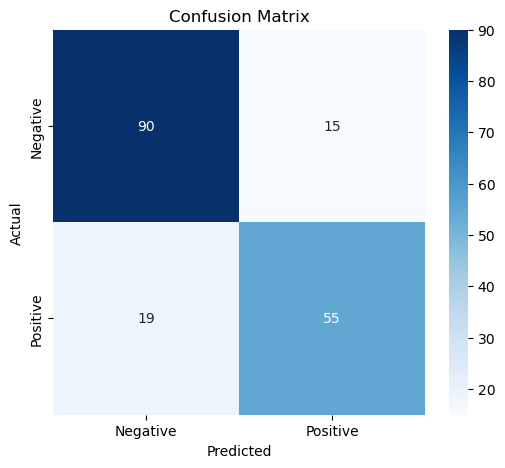

In [11]:
# Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [12]:
print(f'Accuracy: {accuracy:.2f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))


Accuracy: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [ ]:
Q12  Write a Python program to train a Logistic Regression model and evaluate its performance using Precision,
    Recall, and F1-ScoreM

In [67]:

# Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display the results
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Print detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Precision: 0.8667
Recall: 0.8198
F1-Score: 0.8426

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82        89
           1       0.87      0.82      0.84       111

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



Q13  Write a Python program to train a Logistic Regression model on imbalanced data and apply class weights to
    improve model performance

In [13]:


# Generate an imbalanced dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=2, n_redundant=10, n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=42)

# Step 2: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Apply class weights
# The 'balanced' option automatically adjusts weights inversely proportional to class frequencies
class_weights = 'balanced'

# Step 4: Train the Logistic Regression model
model = LogisticRegression(class_weight=class_weights, random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# Step 5: Evaluate the model
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Print ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Print confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       299
           1       1.00      1.00      1.00         1

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

ROC-AUC Score: 1.0000
Confusion Matrix:
[[299   0]
 [  0   1]]


 Q14 Write a Python program to train Logistic Regression on the Titanic dataset, handle missing values, and
    evaluate performance

In [14]:

#read titanic.csv file from working  directory
df = pd.read_csv('titanic.csv')

# Selecting relevant features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
df = df[features + ['Survived']]

# Handling missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encoding categorical variables

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Splitting dataset
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# Evaluating performance
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8101


Q15 Write a Python program to apply feature scaling (Standardization) before training a Logistic Regression
model. Evaluate its accuracy and compare results with and without scaling

In [16]:
df = pd.read_csv('titanic.csv')

# Selecting relevant features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
df = df[features + ['Survived']]

# Handling missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encoding categorical variables

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Splitting dataset
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training Logistic Regression model
model = LogisticRegression()

model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# Evaluating performance
accuracy_with_out_scaling = accuracy_score(y_test, y_pred)


# Standardizing numerical features   (applying feature scaling before training a logistic regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training Logistic Regression model
model = LogisticRegression()

model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# Evaluating performance
accuracy_with_scaling = accuracy_score(y_test, y_pred)
print(f'Accuracy without feature scaling: {accuracy_with_out_scaling:.4f}')
print(f'Accuracy after applying feature scaling (standardization) : {accuracy_with_scaling:.4f}')

Accuracy without feature scaling: 0.7989
Accuracy after applying feature scaling (standardization) : 0.8101


Q16 Write a Python program to train Logistic Regression and evaluate its performance using ROC-AUC score

ROC-AUC Score: 0.9142


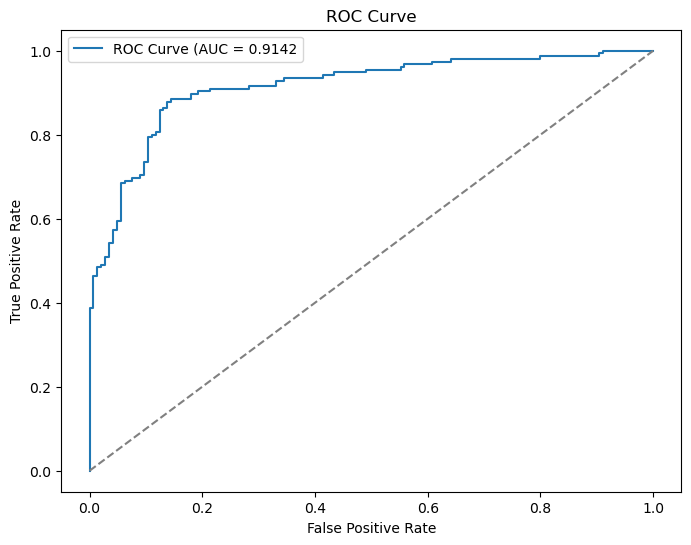

In [73]:

# Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict probabilities
y_probs = model.predict_proba(X_test)[:, 1]

# Compute ROC-AUC score
roc_auc = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
Q17 Write a Python program to train Logistic Regression using a custom learning rate (C=0.5) and evaluate
    accuracy

In [17]:

# Load dataset
data = load_iris()
X, y = data.data, data.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression model with custom learning rate (C=0.5)
model = LogisticRegression(C=0.5, max_iter=200, random_state=42)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 1.0000


 Q18 Write a Python program to train Logistic Regression and identify important features based on model
    coefficientsM

In [75]:



# Load dataset (Iris dataset as an example)
data = load_iris()

df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target

# Split dataset into features and target variable
X = df.drop(columns=['target'])
y = df['target']


# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Evaluate model
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Identify important features
importance = np.abs(model.coef_[0])  # Absolute values of coefficients
important_features = pd.DataFrame({'Feature': data.feature_names, 'Importance': importance})
important_features = important_features.sort_values(by='Importance', ascending=False)

print("\nTop Important Features:")
print(important_features)

Model Accuracy: 1.0000

Top Important Features:
             Feature  Importance
2  petal length (cm)    1.811348
3   petal width (cm)    1.692510
1   sepal width (cm)    1.144873
0  sepal length (cm)    1.003166


Q19 Write a Python program to train Logistic Regression and evaluate its performance using Cohen’s Kappa
    Score 

In [76]:

# Load dataset (Titanic dataset as an example)
df = pd.read_csv('titanic.csv')

# Selecting relevant features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
df = df[features + ['Survived']]

# Handling missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encoding categorical variables

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Splitting dataset
X = df.drop(columns=['Survived'])
y = df['Survived']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the feature set
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
kappa_score = cohen_kappa_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f"Cohen's Kappa Score: {kappa_score:.4f}")


Accuracy: 0.8101
Cohen's Kappa Score: 0.6052


Q20  Write a Python program to train Logistic Regression and visualize the Precision-Recall Curve for binary
classification

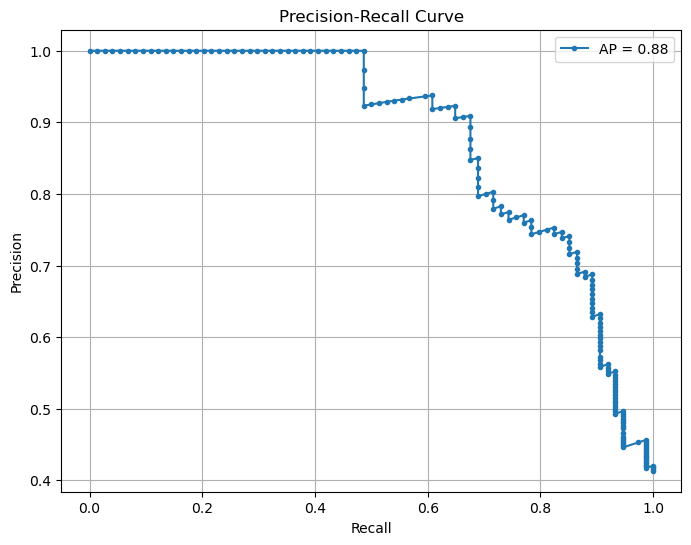

In [77]:

# Load dataset (Titanic dataset as an example)
df = pd.read_csv('titanic.csv')

# Selecting relevant features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
df = df[features + ['Survived']]

# Handling missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encoding categorical variables

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Splitting dataset
X = df.drop(columns=['Survived'])
y = df['Survived']

# Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict probabilities
y_scores = model.predict_proba(X_test)[:, 1]

# Compute Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_scores)

# Compute average precision score
avg_precision = average_precision_score(y_test, y_scores)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'AP = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()


Q21  Write a Python program to train Logistic Regression with different solvers (liblinear, saga, lbfgs) and compare
    their accuracy

Solver: liblinear, Accuracy: 0.9667
Solver: saga, Accuracy: 1.0000
Solver: lbfgs, Accuracy: 1.0000


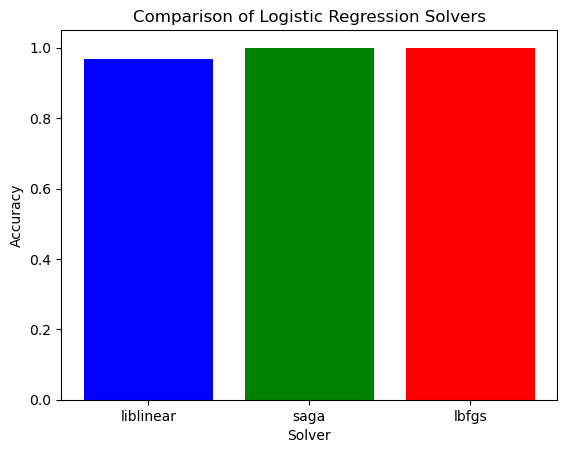

In [78]:

# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# List of solvers to compare
solvers = ['liblinear', 'saga', 'lbfgs']
accuracies = {}

# Train and evaluate models using different solvers
for solver in solvers:
    model = LogisticRegression(solver=solver, max_iter=2000, multi_class='auto', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies[solver] = accuracy
    print(f"Solver: {solver}, Accuracy: {accuracy:.4f}")

# Plot accuracy comparison
plt.bar(accuracies.keys(), accuracies.values(), color=['blue', 'green', 'red'])
plt.xlabel('Solver')
plt.ylabel('Accuracy')
plt.title('Comparison of Logistic Regression Solvers')
plt.show()

Q22 Write a Python program to train Logistic Regression and evaluate its performance using Matthews
    Correlation Coefficient (MCC)

In [79]:



# Load dataset (Titanic dataset as an example)
df = pd.read_csv('titanic.csv')

# Selecting relevant features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
df = df[features + ['Survived']]

# Handling missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encoding categorical variables

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Splitting dataset
X = df.drop(columns=['Survived'])
y = df['Survived']



# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train a Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

Matthews Correlation Coefficient (MCC): 0.6059


Q23 Write a Python program to train Logistic Regression on both raw and standardized data. Compare their
accuracy to see the impact of feature scaling

In [80]:

df = pd.read_csv('titanic.csv')

# Selecting relevant features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
df = df[features + ['Survived']]

# Handling missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encoding categorical variables

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Splitting dataset
X = df.drop(columns=['Survived'])
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training Logistic Regression model
model = LogisticRegression()

model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# Evaluating performance
accuracy_with_raw_data = accuracy_score(y_test, y_pred)


# Standardizing numerical features   (applying feature scaling before training a logistic regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Training Logistic Regression model
model = LogisticRegression()

model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# Evaluating performance
accuracy_with_standardized_data = accuracy_score(y_test, y_pred)
print(f'Accuracy_with_raw_data: {accuracy_with_raw_data:.4f}')
print(f'Accuracy_with_standardized_data  : {accuracy_with_standardized_data :.4f}')

Accuracy_with_raw_data: 0.7989
Accuracy_with_standardized_data  : 0.8101


Q24 Write a Python program to train Logistic Regression and find the optimal C (regularization strength) using
    cross-validationM

Optimal C: 0.046415888336127774
Test Accuracy: 0.8300


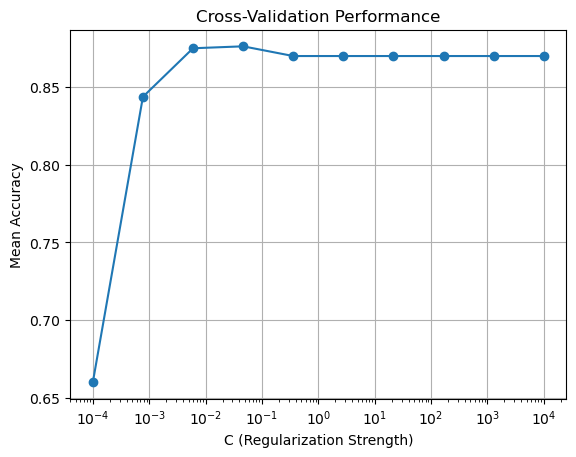

In [81]:

# Generate synthetic classification data
X, y = make_classification(n_samples=1000, n_features=10, random_state=42)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define range of C values for cross-validation
C_values = np.logspace(-4, 4, 10)

# Train Logistic Regression with cross-validation
log_reg_cv = LogisticRegressionCV(Cs=C_values, cv=5, scoring='accuracy', max_iter=1000, random_state=42)
log_reg_cv.fit(X_train, y_train)

# Get the best C value
best_C = log_reg_cv.C_[0]
print(f"Optimal C: {best_C}")

# Evaluate on test data
y_pred = log_reg_cv.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Plot mean accuracy for each C value
mean_scores = log_reg_cv.scores_[1].mean(axis=0)
plt.semilogx(C_values, mean_scores, marker='o')
plt.xlabel('C (Regularization Strength)')
plt.ylabel('Mean Accuracy')
plt.title('Cross-Validation Performance')
plt.grid(True)
plt.show()


 Q25 Write a Python program to train Logistic Regression, save the trained model using joblib, and load it again to
    make predictions.

In [82]:

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression model
model = LogisticRegression(multi_class='ovr', solver='liblinear')
model.fit(X_train, y_train)

# Save the trained model
joblib.dump((model, scaler), 'logistic_regression_model.pkl')
print("Model saved successfully.")

# Load the model
loaded_model, loaded_scaler = joblib.load('logistic_regression_model.pkl')
print("Model loaded successfully.")

# Make predictions
y_pred = loaded_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy: {accuracy:.2f}")


Model saved successfully.
Model loaded successfully.
Model accuracy: 0.97
